<font size = "10"><span style="color: lightgrey">Quiz 4 Resources</span>

In [1]:
#import packages
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import os

In [ ]:
#Question 1
#You will be given a code cell that calculates the coefficients of a quadratic model () between two variables. 
# All code in this cell will be correct. 
# Then in the next code cell, a figure is generated with a scatter plot of the individual data and a line plot of the model prediction. 
# However, the plot is obviously wrong. Make necessary modifications to generate a correct plot.

b = coeffs["Intercept"]
a = coeffs["weight"]

x_data = df_cars["weight"]
y_data_scatter = df_cars["mpg"]
y_data_plot = b + a*df_cars["weight"]

plt.scatter(x_data, y_data_scatter)
plt.plot(x_data, y_data_plot, color="red")
plt.legend(["Data", "Best Fit Line"])
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Car Weight vs. MPG")
plt.show()



In [ ]:
#Question 2
#Read in a .csv file to create a DataFrame which contains weather data for Delhi, India in the year 2017. 
# Using the ".plot()" method, generate a single line plot with (time vs. temperature) and (time vs. wind speed). 
# The ".plot()" method is the one connected to a Pandas DataFrame, not the one in the matplotlib.pyplot library.

df_financial = pd.read_csv("data_raw/financial.csv")

# Step 1 of chain:
# Grab columns we want to plot

df_financial[   ["date","sp500","djia"]   ]
# Step 2 of chain:
# We will plot the date on the x-axis.
# So we will make "date" the index column

df_financial[   ["date","sp500","djia"]   ].set_index("date")

# Step 3 of chain:
# We will use the DataFrame's .plot method.
# This will plot index vs. column 1 AND
# will plot index vs. column 2

df_financial[   ["date","sp500","djia"]   ].set_index("date").plot()

ax = df_financial[   ["date","sp500","djia"]   ].set_index("date").plot()
ax.set_title("S&P 500 and Dow Jones over Time")
ax.set_xlabel("Time")
ax.legend( ["S&P 500", "Dow Jones"] )
ax.set_ylabel("??????")
plt.show()


In [ ]:
#Question 3
#Read in a .csv file to create a DataFrame which contains conversion rates for Euros to U.S. dollars and British Pounds to U.S. dollars over time. 
# Compute non-dimensional percentage growth values for each and plot together on a single plot. 
# (You can use matplotlib.pyplot or the .plot() method connected to a DataFrame).

# Let's calculate the numerator: the difference between today's index 
# and yesterday's index.

df_financial["date"] = pd.to_datetime(df_financial["date_str"])
display(df_financial.head())

df_financial["diff_sp500"] = df_financial["sp500"].diff()

display(df_financial[["date", "sp500", "diff_sp500"]])

# Let's make the denominator: "yesterday's index"
# Also known as the "lag"

# ".shift(1)" computes a new column with the value of "sp500"
# one period before. By convention the first column is assigned
# a missing value

df_financial["lag_sp500"] = df_financial["sp500"].shift(1)

display(df_financial[["date", "sp500", "diff_sp500", "lag_sp500"]])

# Now we combine ".diff()" and ".shift()" to compute growth rates

df_financial["growth_sp500"] = (df_financial["diff_sp500"]/
    df_financial["lag_sp500"]) * 100

display(df_financial[["date", "sp500", "growth_sp500", "diff_sp500", 
    "lag_sp500"]])

plt.plot("date", "growth_sp500",
          data = df_financial)
plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("Change in the S&P 500 Index")
plt.show()

df_financial["growth_djia"] = (df_financial["djia"].diff()
         / df_financial["djia"].shift(1) )* 100

plt.plot("date", "growth_sp500",
          data = df_financial)
plt.plot("date", "growth_djia",
          data = df_financial,alpha = 0.75)
plt.xlabel("Time")
plt.ylabel("Daily percentage change ")
plt.title("Change in the stock market funds")
plt.legend(["S&P 500", "DJIA"])
plt.show()


In [ ]:
#Question 4
#Continuing with the DataFrame of conversion rates, create a new column of Boolean type, 
# which checks whether the conversion rate for one of the currencies was greater than a given value.

# Add a column called "covid_period" of Boolean type.
# "True" if date is between March 1st, 2020 and May 1st, 2020
df_financial["covid_period"]  = df_financial["date"].between("2020-03-01","2020-05-01")

display(df_financial.head())
display(df_financial.dtypes)

df_financial["covid_period"]  = df_financial["date"].between("2020-03-01","2020-05-01")
df_financial["new"] = df_financial["sp500"] > 2600

display(df_financial.head())
display(df_financial.dtypes)

In [ ]:
#Question 5
#Continuing Problem 4, make a line plot of the conversion rate for this currency and highlight regions where the conversion rate is 
# larger than a given value, using the function "plt.fill_between"

# Create a line plot

plt.plot("date", "growth_djia", data = df_financial, 
    label="_nolegend_")
plt.xlabel("Date")
plt.ylabel("Dow Jones Percentage Growth")


# Add shaded region(s) with plt.fill_between
condition = abs(df_financial["growth_djia"]) > 3

plt.fill_between(x = x_vals,
                 y1 = y_vals.min(),
                 y2 = y_vals.max(),
                 where = condition,
                 alpha = 0.2,color = "red",
                 label = "Periods of large change")

plt.legend()

# show the plot
plt.show()



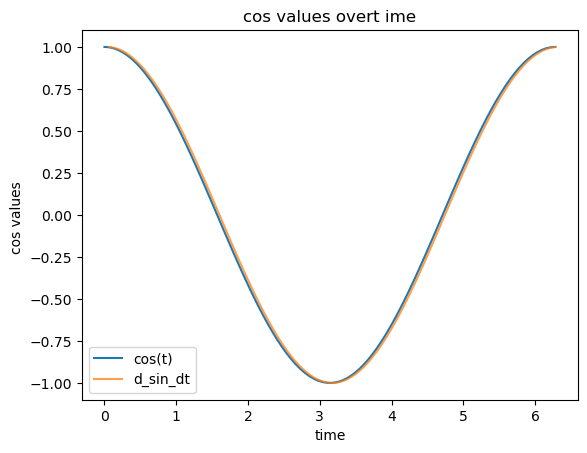

In [5]:
#Question 6
#A code cell creates a DataFrame with the following columns. All columns are numerical:

#time: A column containing evenly spaced values between 0 and 2pi. Denote them by 
#sin: A column containing the sine function evaluated at those points. I.e. 
#cos: A column containing the cosine function evaluated at those points. I.e. 
#Using the ".diff()" method, create a new column called "d_sin_dt" with the following formula: .

#From calculus, this should be close to , so plot (time vs. cos) and (time vs. d_sin_dt) together on a single figure to it.
# Create evenly spaced time values between 0 and 2π
time = np.linspace(0, 2 * np.pi, 100)



# Create DataFrame
df = pd.DataFrame({
    'time': time,
    'sin': np.sin(time),
    'cos': np.cos(time)
})

df['d_sin_dt'] = df['sin'].diff() / df['time'].diff()

plt.plot("time", "cos",
          data = df)
plt.plot("time", "d_sin_dt",
          data = df,alpha = 0.75)
plt.xlabel("time")
plt.ylabel("cos values ")
plt.title("cos values overt ime")
plt.legend(["cos(t)", "d_sin_dt"])
plt.show()





